# Import Libraries

In [ ]:
import re
import nltk
import spacy


In [ ]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

#Input Data

In [ ]:
inputText = "This is the quickly #RISE of Phoenix !!!"

# Step 1 : Lowercase conversion

In [ ]:
input_lower = inputText.lower()
print(input_lower)

this is the quickly #rise of phoenix !!!


# Step 2 : Remove Special charaters from Input string

In [ ]:
input = re.sub(r"[^a-z\s]","",input_lower)
print(input)

this is the quickly rise of phoenix 


# Step 3 : Remove Stopwords

In [ ]:
stop_words = set(stopwords.words("english"))
print(stop_words)

{'your', 'are', 'am', 'below', 'hasn', "i'm", 'his', "you've", "hadn't", 'should', 'for', 'until', 'too', "it's", 'does', 'it', 'hers', 'than', "we've", 'wouldn', 'have', 't', 'why', 'that', 'what', "i've", "we're", 'now', "they'd", 'against', 'which', "wouldn't", 'were', 'been', 'ma', 'other', 'these', 'but', 'wasn', "haven't", 'm', 'him', 'didn', 'some', 've', 'this', 'theirs', "you'd", 'their', 'at', "it'll", 'after', "we'll", 'into', "don't", 'up', 'our', "they'll", 'whom', "mightn't", 'once', 'itself', 'during', "she'd", "she's", "you'll", "i'd", 'will', "wasn't", "he'll", 'won', 'before', 'did', 'out', 'don', 'then', 'on', 'under', 'between', "doesn't", 'myself', 'all', 'if', "shan't", 'because', "didn't", 'yours', "that'll", 'y', 'again', 'such', 'very', 'in', 'where', 'its', 'yourselves', 'an', 'and', 'shouldn', "weren't", 'himself', 'had', 'any', 'more', 'he', 'mustn', "mustn't", 'own', 'them', 'you', 'through', 'my', 'she', 'each', 'herself', 'about', 'the', 'being', 'with', 

In [ ]:
print(f"Len({len(stop_words)})")

Len(198)


In [ ]:
input_NoStopWord = " ".join(word for word in input.split() if word not in stop_words)
print(f"Original: {input}\n")
print(f"Stop words removed: {input_NoStopWord}")

Original: this is the quickly rise of phoenix 

Stop words removed: quickly rise phoenix


# Step 4: Stemming

In [ ]:
stemmer = PorterStemmer()
stemmed = " ".join(stemmer.stem(w) for w in input_NoStopWord.split())
print(f"stemmed : {stemmed}")

stemmed : quickli rise phoenix


# Step 5: Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()
lemma = " ".join(lemmatizer.lemmatize(w) for w in input_NoStopWord.split())
print(f"lemmatization : {lemma}")

lemmatization : quickly rise phoenix


# Step 4 and Step 5 : Stemming and Lemmatization using spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("dogs running quickly parks")
for token in doc:
  print(f"{token.text:12}")

dogs        
running     
quickly     
parks       


# Step 6 : TOKENISATION

In [ ]:
import nltk
import spacy
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Token using nltk

word_tokenize : Breaks a sentence into words and punctuation tokens.

In [ ]:
text = "Neeraj said, i am feeling ok!"
tokens = nltk.word_tokenize(text)
tokens

['Neeraj', 'said', ',', 'i', 'am', 'feeling', 'ok', '!']

# Token using nlp

In [ ]:
doc = nlp(text)
tokens_sp = [token.text for token in doc]
tokens_sp

['Neeraj', 'said', ',', 'i', 'am', 'feeling', 'ok', '!']

sent_tokenize : Breaks a paragraph into sentences.

NLP Pipeline Usage

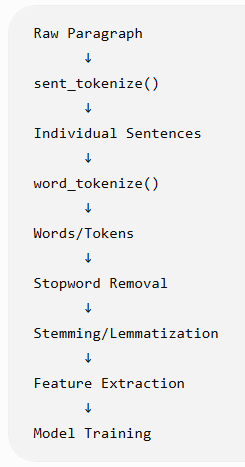

In [ ]:
text = """Modern humans arrived on the Indian subcontinent from Africa no later than 55,000 years ago.
 Their long occupation, predominantly in isolation as hunter-gatherers,
has made the region highly diverse. Settled life emerged on the subcontinent in the
western margins of the Indus river basin 9,000 years ago, evolving gradually into the
Indus Valley Civilisation of the third millennium BCE. By 1200 BCE, an archaic form of Sanskrit,
an Indo-European language, had diffused into India from the northwest. Its hymns
recorded the early dawnings of Hinduism in India"""

sent_token = nltk.sent_tokenize(text)

for i,sent in enumerate(sent_token):
  print(f"  Sentence {i+1} : {sent}")

  Sentence 1 : Modern humans arrived on the Indian subcontinent from Africa no later than 55,000 years ago.
  Sentence 2 : Their long occupation, predominantly in isolation as hunter-gatherers,
has made the region highly diverse.
  Sentence 3 : Settled life emerged on the subcontinent in the
western margins of the Indus river basin 9,000 years ago, evolving gradually into the
Indus Valley Civilisation of the third millennium BCE.
  Sentence 4 : By 1200 BCE, an archaic form of Sanskrit,
an Indo-European language, had diffused into India from the northwest.
  Sentence 5 : Its hymns
recorded the early dawnings of Hinduism in India


#LLM uses special kind of subword tokenization

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
subword_tokens = tokenizer.tokenize("unhappiness is problematic")
subword_tokens

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

['un', '##ha', '##pp', '##iness', 'is', 'problematic']

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [2]:
docs = ["the cat sat",
        "the dog sat",
        "the dog and the cat"]

bow_vector = CountVectorizer()
bow_matrix = bow_vector.fit_transform(docs) #this is the line where magic happens, miracle
bow_df = pd.DataFrame(bow_matrix.toarray(),columns=bow_vector.get_feature_names_out())
bow_df

,and,cat,dog,sat,the
0,0,1,0,1,1
1,0,0,1,1,1
2,1,1,1,0,2


In [3]:
docs = ["the cat sat",
        "the dog sat",
        "the dog and the cat"]

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(docs)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),columns=tfidf_vec.get_feature_names_out())
tfidf_df

,and,cat,dog,sat,the
0,0.000000,0.619805,0.000000,0.619805,0.481334
1,0.000000,0.000000,0.619805,0.619805,0.481334
2,0.530587,0.403525,0.403525,0.000000,0.626747
